## CT reconstruction from a LCDT: A Deep Learning problem approached via Mecchanical Statistics

### What is A CT and a LCDT: *
A CT (Computed Tomography) is a medical imaging technique used to obtain detailed internal images of the body by combining multiple X-ray measurements taken from different angles. It produces cross-sectional images (slices) that help in diagnosing diseases and injuries.

An LDCT (Low-Dose Computed Tomography) is a specialized form of CT scan that uses a significantly lower amount of radiation compared to standard CT, while still providing sufficient image quality for clinical diagnosis. LDCT is often used for screening purposes, such as early detection of lung cancer, to reduce the risk associated with radiation exposure.

## The Problem...*
Although CT scans are invaluable for medical diagnosis, repeated exposure to ionizing radiation from multiple scans can increase the risk of developing cancer. This is particularly concerning for patients who require frequent imaging, such as those with chronic illnesses or undergoing cancer screening programs. Low-Dose CT (LDCT) reduces radiation exposure, but the images are noisier and lower quality, which complicates accurate diagnosis.

Studies have shown that repeated CT scans, especially in vulnerable populations like children, can significantly raise the risk of cancers such as brain tumors and leukemia. For example, research highlighted by Cancer Research UK points out that two or three head CT scans in childhood may triple the risk of brain tumors later in life, and five or more can triple the risk of leukemia (source).

This creates a strong motivation to develop advanced reconstruction and denoising techniques that can extract high-quality images from LDCT scans, minimizing radiation dose without compromising diagnostic accuracy.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We simulate LDCT noise by modeling each pixel intensity $x_i$ as the mean of a Poisson distribution. To mimic the reduced number of photons in low-dose scans, the mean is scaled by the dose factor:

$$
\lambda = \text{dose} \times \left(\frac{x_i}{x_{\max}}\right) \times 255
$$

Here, $x_i$ is normalized by the maximum pixel intensity $x_{\max}$ to bring values into $[0,1]$, then multiplied by 255 to match the typical 8-bit intensity scale. The dose factor $\text{dose} < 1$ reduces the expected photon count.

The noisy pixel $x_i^{noisy}$ is then sampled as:

$$
x_i^{noisy} \sim \text{Poisson}(\lambda)
$$

Finally, the sampled value is rescaled back to the original intensity range by reversing the normalization and dose scaling, ensuring the noisy image remains comparable to the original.



In [ ]:
#NON RUNNARE (lungo e rischio di sovrascrivere)!!!
import os
import numpy as np
from PIL import Image

#cartella D45 su cui simuliamo rumore poissoniano
input_root = "/content/drive/MyDrive/Sharp Kernel (D45)_NCDT"
output_root = "/content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated"
dose_factor = 0.25  # 25% di riduzione di grafica dell'LCDT

os.makedirs(output_root, exist_ok=True)

# Funzione per aggiungere rumore Poissoniano
def add_poisson_noise(img, dose=0.25):
    img = img.astype(np.float32)

    # Normalizza in [0, 1] e scala alla "dose" simulata
    img_scaled = img / img.max()
    img_dose = img_scaled * dose * 255 #data la dose simula il nuovo valore del pixel

    # Applica rumore Poissoniano
    noisy = np.random.poisson(img_dose).astype(np.float32)

    # Riscala all'intervallo [0,255]
    noisy = noisy / (dose * 255)
    noisy = np.clip(noisy * 255, 0, 255).astype(np.uint8)
    return noisy

# lo faccio per tutte le cartelle in NCDT_D45
for foldername in os.listdir(input_root):
    folder_path = os.path.join(input_root, foldername)

    if os.path.isdir(folder_path):
        output_folder = os.path.join(output_root, foldername)
        os.makedirs(output_folder, exist_ok=True)

        for filename in os.listdir(folder_path):
            if filename.endswith(".png"):
                input_path = os.path.join(folder_path, filename)
                output_path = os.path.join(output_folder, filename)

                try:
                    img = Image.open(input_path).convert("L")
                    img_array = np.array(img)

                    # Aggiungi rumore
                    img_noisy = add_poisson_noise(img_array, dose=dose_factor)

                    # Salva
                    noisy_img = Image.fromarray(img_noisy)
                    noisy_img.save(output_path)
                    print(f" Saved: {output_path}")
                except Exception as e:
                    print(f"Error: {e} on {input_path}")


 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0006.2016.01.21.18.13.51.297560.405166499.png
 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0023.2016.01.21.18.13.51.297560.405201765.png
 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0026.2016.01.21.18.13.51.297560.405201837.png
 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0004.2016.01.21.18.13.51.297560.405166451.png
 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0001.2016.01.21.18.13.51.297560.405166379.png
 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0027.2016.01.21.18.13.51.297560.405201861.png
 Saved: /content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0008.2016.01.21.18.13.51.297560.405166547.png
 Saved

##  Let's start with CT scans!

From the Kaggle dataset [CT Low Dose Reconstruction](https://www.kaggle.com/datasets/andrewmvd/ct-low-dose-reconstruction), we import the normal-dose CT (NCDT) images and simulate low-dose CT (LCDT) images by adding Poisson noise.

For simplicity, we focus only on the **D45** images, which use a sharp reconstruction kernel that highlights fine details. This allows us to clearly see the difference between an original NCDT image and its noisy, simulated LCDT counterpart.

Our goal is to visually and quantitatively compare the impact of dose reduction on image quality.  
Ready? Let's dive in!


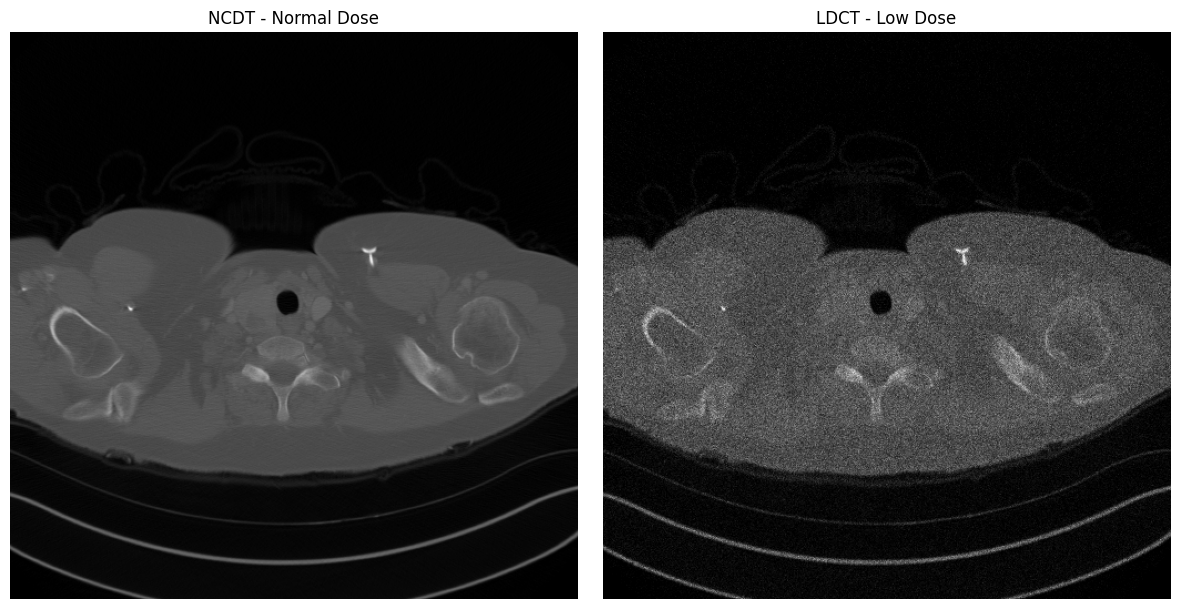

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Percorsi delle immagini
img1_path = '/content/drive/MyDrive/Sharp Kernel (D45)_NCDT/L096/L096_FD_3_SHARP_1.CT.0005.0001.2016.01.21.18.13.51.297560.405166379.png'
img2_path = '/content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096/L096_FD_3_SHARP_1.CT.0005.0001.2016.01.21.18.13.51.297560.405166379.png'

# Lettura immagini
img1 = Image.open(img1_path)
img2 = Image.open(img2_path)

# Conversione in scala 0-255 in maniera robusta
def to_0_255(img):
    arr = np.array(img, dtype=np.float32)  # usa float per evitare overflow
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max > arr_min:
        arr = (arr - arr_min) / (arr_max - arr_min) * 255
    return arr.astype(np.uint8)

img1_np = to_0_255(img1)
img2_np = to_0_255(img2)

# Visualizzazione affiancata
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img1_np, cmap='gray', vmin=0, vmax=255)
plt.title('NCDT - Normal Dose')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_np, cmap='gray', vmin=0, vmax=255)
plt.title('LDCT - Low Dose')
plt.axis('off')

plt.tight_layout()
plt.show()


### 8-Connected Graph Representation of CT Images

We model each 512×512 CT image as a graph where each pixel is a node connected to its 8 neighbors (horizontal, vertical, and diagonal). This captures rich local spatial relationships important for texture and smoothness while keeping computational complexity manageable.

This 8-neighbor structure aligns with classical lattice models in statistical mechanics, enabling the use of established tools. For example, an 8×8 block with 256 intensity levels per pixel has a state space of $256^{8\times 8}$, which is large but far smaller than the full image, making Boltzmann-Gibbs modeling feasible on such sub-blocks.

This approach also supports downsampling (e.g., pooling 8×8 blocks) that preserves local dependencies. Overall, the 8-connected graph sets a solid foundation for statistical mechanics-inspired methods to model pixel interactions, improving CT image denoising and reconstruction.



### Boltzmann-Gibbs Pooling with Local Hamiltonian on 4×4 Blocks

To perform pooling on a 4×4 pixel block of the image, we define a local energy for each pixel based on the Hamiltonian:

$$
H(x_i) = \sum_{j \in \mathcal{N}(i)} (x_i - x_j)^2
$$

where $\mathcal{N}(i)$ denotes the set of 8-connected neighbors of pixel $i$ within the block.

This local energy measures how different the intensity of pixel $i$ is from its neighbors, encouraging smoothness.

We then define a Boltzmann-Gibbs distribution over the pixels in the block as:

$$
p(x_i) = \frac{e^{-\ H(x_i)}}{\sum_{k=1}^{16} e^{-\ H(x_k)}}
$$


Finally, the pooled pixel value representing the whole block is computed as the expected value:

$$
\langle x \rangle = \sum_{i=1}^{16} x_i \, p(x_i)
$$

This pooling method preserves local structure by giving higher weight to pixels whose intensities are more consistent with their neighbors.



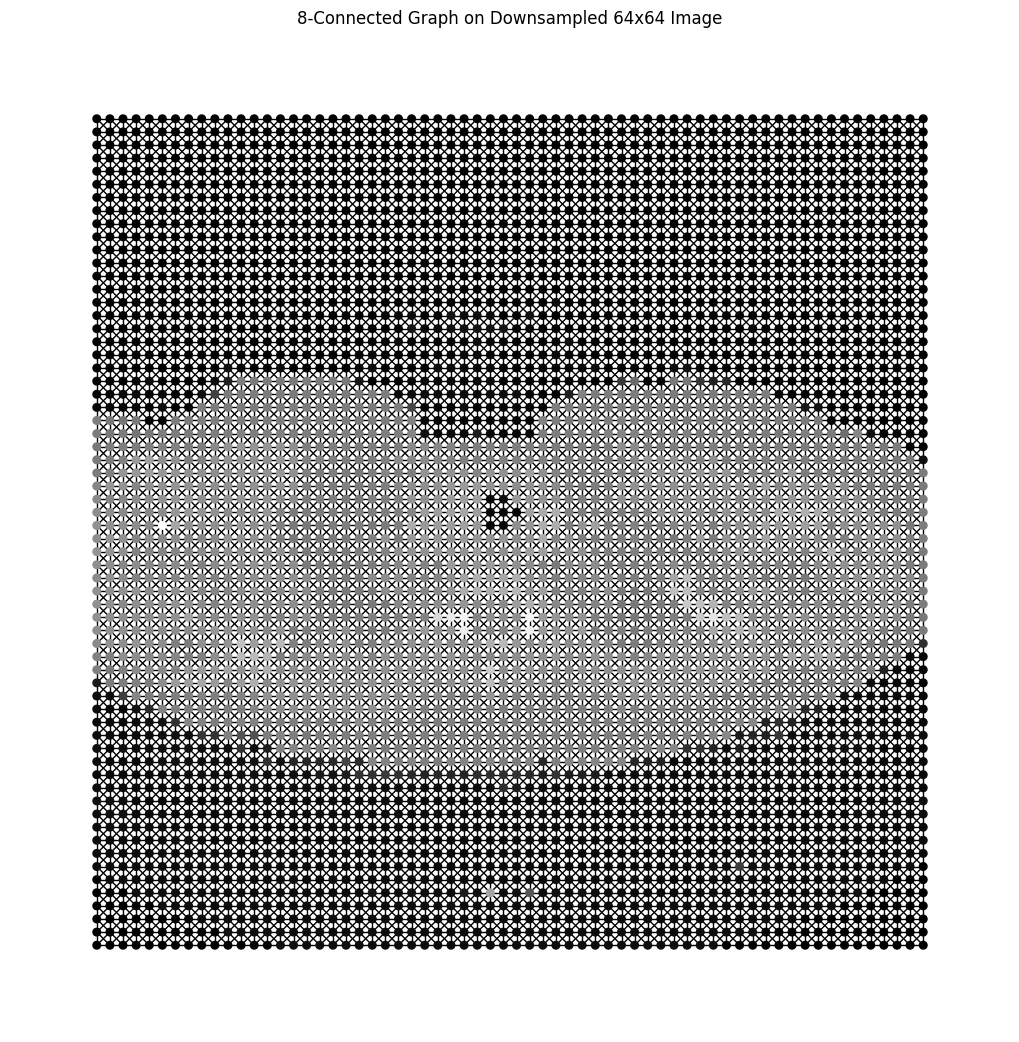

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def boltzmann_gibbs_pooling(block):
    rows, cols = block.shape
    assert rows == 8 and cols == 8, "Block must be 8x8"

    neighbors = [(-1,0), (1,0), (0,-1), (0,1),
                 (-1,-1), (-1,1), (1,-1), (1,1)]

    energies = np.zeros((rows, cols), dtype=np.float64)

    for r in range(rows):
        for c in range(cols):
            xi = float(block[r, c])
            energy = 0.0
            for dr, dc in neighbors:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    xj = float(block[nr, nc])
                    energy += (xi - xj) ** 2
            energies[r, c] = energy

    exp_neg_H = np.exp(-energies.flatten())
    Z = np.sum(exp_neg_H)
    probs = exp_neg_H / Z

    values = block.flatten()
    expected_value = np.sum(values * probs)

    return expected_value

def downsample_image_boltzmann_gibbs(img):
    rows, cols = img.shape
    assert rows % 8 == 0 and cols % 8 == 0, "Image dimensions must be divisible by 8"

    new_rows, new_cols = rows // 8, cols // 8
    downsampled = np.zeros((new_rows, new_cols), dtype=np.float64)

    for i in range(new_rows):
        for j in range(new_cols):
            block = img[i*8:(i+1)*8, j*8:(j+1)*8]
            pooled_value = boltzmann_gibbs_pooling(block)
            downsampled[i, j] = pooled_value

    return downsampled

def image_to_graph_8_connected(img):
    rows, cols = img.shape
    G = nx.Graph()
    for r in range(rows):
        for c in range(cols):
            G.add_node((r, c), intensity=float(img[r, c]))
    neighbors = [(-1,0), (1,0), (0,-1), (0,1),
                 (-1,-1), (-1,1), (1,-1), (1,1)]
    for r in range(rows):
        for c in range(cols):
            for dr, dc in neighbors:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    if (r, c) < (nr, nc):
                        G.add_edge((r, c), (nr, nc))
    return G

# Convert one of the loaded images to a numpy array
img_np = np.array(img1)

# Applica downsampling con Gibbs
downsampled_img = downsample_image_boltzmann_gibbs(img_np)
G_downsampled = image_to_graph_8_connected(downsampled_img)

# Plot del grafo 64x64
pos = {node: (node[1], -node[0]) for node in G_downsampled.nodes()}
plt.figure(figsize=(10, 10))

node_colors = [downsampled_img[node[0], node[1]] for node in G_downsampled.nodes()]
nx.draw(G_downsampled, pos, node_size=30, node_color=node_colors, cmap=plt.cm.gray, with_labels=False)

plt.title("8-Connected Graph on Downsampled 64x64 Image")
plt.axis('off')
plt.show()

### From the 64×64 Noise Graph to the 512×512 Denoised Image

Now we have our noisy graph of size $64 \times 64$, and we want to reconstruct denoised images of size $512 \times 512$. One possible approach is to enforce that each node of the graph converges to the corresponding value in the clean NCDT image, i.e.,

$$
x \to x_{NCDT}.
$$

Mathematically, this means defining a dynamics for the node values $x$ such that they evolve toward $x_{NCDT}$. Since pixel values are spatially dependent, we cannot simply use mean-field theory; instead, we want the dynamics to converge to a configuration that minimizes the difference between the dynamic state $x_{\text{lang}}$ and the clean image $x_{NCDT}$.

For this, we use a Langevin dynamics defined as:

$$
dx_t = - \nabla_x \mathcal{H}(x_t) \, dt + \sqrt{2 \beta^{-1}} \, dW_t,
$$

where $\mathcal{H}(x)$ is the Hamiltonian that encodes the correlation between neighboring pixels and fidelity to the original LDCT image. We choose this Hamiltonian because it encourages $x_{\text{lang}}$ to remain close to $x_{NCDT}$ while preserving local pixel interactions.

Our goal translates into finding the optimal interaction parameters $J_{ij}$ that minimize the **expected mean squared error** over the stochastic Langevin dynamics:

$$
\min_{J} \; \mathcal{L}(J) = \mathbb{E}_{x_{\text{lang}}(J)} \left[ \left\| x_{\text{lang}}(J) - x_{\text{NCDT}} \right\|^2 \right]
$$

where the expectation is taken over the randomness introduced by the Langevin noise in the dynamics. In practice, this expectation is approximated by averaging over multiple stochastic simulations of the Langevin dynamics:

$$
\mathcal{L}(J) \approx \frac{1}{K} \sum_{k=1}^{K} \left\| x_{\text{lang}}^{(k)}(J) - x_{\text{NCDT}} \right\|^2,
$$

where each $x_{\text{lang}}^{(k)}(J)$ is a sample obtained from one run of the Langevin dynamics with independent noise.

This objective function will effectively become our loss during training.

To numerically solve the Langevin dynamics and compute $x(t)$ at each step, we will use the **Euler–Maruyama method**, a numerical integration scheme specifically designed for stochastic differential equations, which appropriately handles both the deterministic drift and stochastic noise terms.






We define the Hamiltonian for the Langevin dynamics as

$$
\mathcal{H}(x) = \sum_{\langle i,j \rangle} J_{ij} (x_i - x_j)^2 + \lambda \sum_i (x_i - x_i^{(0)})^2,
$$

where $x_i^{(0)}$ is the initial noisy pixel value (from LDCT).

We use this form because it balances smoothing the image by enforcing local consistency between neighbors and keeping the solution close to the original noisy input, which is essential for the Langevin dynamics to converge to a meaningful denoised image.


We train our model to denoise LDCT images by minimizing the Hamiltonian-based loss:

$$
\mathcal{H}(x) = \sum_{\langle i,j \rangle} J_{ij} (x_i - x_j)^2 + \lambda \sum_i (x_i - x_i^{(0)})^2,
$$

where $x_i^{(0)}$ are the initial noisy pixel values from the LDCT images.

As before, we consider an 8-connected neighborhood for each pixel, meaning each pixel interacts with its 8 spatial neighbors (horizontal, vertical, and diagonal).

The training uses paired images from two folders:

- LDCT noisy images from `/content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated`
- Clean NCDT images from `/content/drive/MyDrive/Sharp Kernel (D45)_NCDT`

We optimize the parameters \(J_{ij}\) so that the Langevin dynamics applied to \(x\) converges close to the clean images, minimizing

$$
\min_{J} \| x(J)_{\text{lang}} - x_{\text{NCDT}} \|^2.
$$

This end-to-end training enables the model to learn pixel interaction patterns useful for effective denoising.


### Langevin Dynamics Convergence Criterion

We use **Langevin dynamics** to sample from a target distribution

$$
p(x) \propto e^{-\beta H(x)}
$$

where $H(x)$ is the energy (Hamiltonian).

Since we don't know the normalization constant $Z$, we cannot directly compare distributions $p(x)$ and $q(x) \propto e^{-\beta H(x)}$.

However, the **Kullback-Leibler divergence** can be written (up to constants) as:

$$
D_{KL}(p \parallel q) = \mathrm{const} - \beta \, \mathbb{E}_{p}[H(x)]
$$

Therefore, monitoring the expected energy $\mathbb{E}_{p}[H(x)]$ under the empirical distribution $p$ (represented by Langevin samples) gives an indirect measure of how close we are to convergence.

We estimate this expectation empirically as the average energy over a batch of $B$ samples and $N$ Langevin trajectories:

$$
\mathbb{E}_{p}[H(x)] \approx \frac{1}{B \cdot N} \sum_{i=1}^B \sum_{j=1}^N H(x_{i,j})
$$

where $x_{i,j}$ is the $j$-th Langevin sample for the $i$-th batch element.

We iterate the Langevin updates until the change in this expected energy between consecutive steps is below a tolerance $\varepsilon$:

$$
\left| \mathbb{E}_{p_t}[H(x)] - \mathbb{E}_{p_{t-1}}[H(x)] \right| < \varepsilon
$$

This stopping criterion approximates convergence of the sampling distribution to the target equilibrium distribution.


In [ ]:
# === IMPORTS ===
import os
import gc
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

# === DEVICE ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === DATASET ===
class CTDataset(Dataset):
    def __init__(self, ldct_folder, ncdt_folder):
        self.pairs = []
        ldct_files = sorted([f for f in os.listdir(ldct_folder) if f.endswith(".png")])
        ncdt_files = sorted([f for f in os.listdir(ncdt_folder) if f.endswith(".png")])
        common_files = sorted(set(ldct_files).intersection(ncdt_files))
        for filename in common_files:
            self.pairs.append((os.path.join(ldct_folder, filename),
                               os.path.join(ncdt_folder, filename)))
        if len(self.pairs) == 0:
            raise RuntimeError("Nessuna coppia valida trovata")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ldct_path, ncdt_path = self.pairs[idx]
        try:
            ldct_img = np.array(Image.open(ldct_path).convert("L"), dtype=np.float32)
            ncdt_img = np.array(Image.open(ncdt_path).convert("L"), dtype=np.float32)
            ldct = torch.from_numpy(ldct_img).unsqueeze(0).float()
            ncdt = torch.from_numpy(ncdt_img).unsqueeze(0).float()
            return ldct, ncdt
        except UnidentifiedImageError as e:
            print(f"Warning: Skipping corrupted image pair {ldct_path}, {ncdt_path} due to error: {e}")
            return None

# === DATA LOADER ===
ldct_root = "/content/drive/MyDrive/Sharp Kernel (D45)_LDCT simulated/L096"
ncdt_root = "/content/drive/MyDrive/Sharp Kernel (D45)_NCDT/L096"
dataset = CTDataset(ldct_root, ncdt_root)
dataset = [item for item in dataset if item is not None]
train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

# === HYPERPARAMS ===
beta_inv = 1.0
delta_t = 0.01
max_epochs = 5
max_langevin_steps = 100
langevin_energy_tol = 1e-4
neighbors_8 = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(1,-1),(-1,1),(1,1)]
T_min, T_max = 10, 50  # passi Langevin casuali

def annealing_lambda(epoch, lambda_start=5.0, lambda_end=0.1, max_epochs=10):
    return lambda_end + (lambda_start - lambda_end) * torch.exp(torch.tensor(-5*epoch/max_epochs)).item()

# === PARAMETER TO LEARN ===
# J come matrice 8 x H x W (un peso per ciascun vicino)
sample_img = dataset[0][0]
H, W = sample_img.shape[1], sample_img.shape[2]
J = torch.nn.Parameter(torch.ones(8, H, W, device=device) * 0.1, requires_grad=True)
optimizer = optim.Adam([J], lr=0.01)
mse_loss = nn.MSELoss()

# === FUNCTIONS ===
def hamiltonian(x, y, J, neighbors, lambda_reg):
    diff = torch.zeros_like(x, device=x.device)
    for n, (di, dj) in enumerate(neighbors):
        x_shifted = torch.roll(x, shifts=(di, dj), dims=(2,3))
        diff += J[n] * (x - x_shifted)**2
    fidelity = lambda_reg * (x - y)**2
    H_val = diff.sum(dim=(-2,-1)) + fidelity.sum(dim=(-2,-1))
    return H_val

def hamiltonian_gradient(x, y, J, neighbors, lambda_reg):
    grad = torch.zeros_like(x)
    for n, (di,dj) in enumerate(neighbors):
        x_shifted = torch.roll(x, shifts=(di,dj), dims=(2,3))
        grad += 2 * J[n] * (x - x_shifted)
    grad += 2 * lambda_reg * (x - y)
    return grad

def langevin_step(x, y, beta_inv, delta_t, J, neighbors, lambda_reg):
    grad = hamiltonian_gradient(x, y, J, neighbors, lambda_reg)
    noise = torch.randn_like(x) * torch.sqrt(torch.tensor(2.0 * beta_inv * delta_t, device=x.device))
    return x - grad * delta_t + noise

# === TRAINING LOOP ===
for epoch in range(1, max_epochs+1):
    lambda_reg = annealing_lambda(epoch)
    epoch_loss = 0.0
    total_samples = 0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        batch_x = batch_x.to(device) / 255.0
        batch_y = batch_y.to(device) / 255.0

        x = batch_x.clone()
        prev_energy = float('inf')
        T = random.randint(T_min, T_max)

        for _ in range(T):
            x = langevin_step(x.unsqueeze(1), batch_y.unsqueeze(1), beta_inv, delta_t, J, neighbors_8, lambda_reg)
            x = x.squeeze(1)
            current_energy = hamiltonian(x.unsqueeze(1), batch_y.unsqueeze(1), J, neighbors_8, lambda_reg).mean().item()
            if abs(current_energy - prev_energy) < langevin_energy_tol:
                break
            prev_energy = current_energy

        loss = mse_loss(x, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total_samples += 1

        if (batch_idx+1) % 5 == 0:
            torch.cuda.empty_cache()
            gc.collect()

    avg_loss = epoch_loss / total_samples
    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}, J mean: {J.mean().item():.4f}, Lambda: {lambda_reg:.4f}")
    torch.cuda.empty_cache()
    gc.collect()

print("Training finished and CUDA cache cleared.")

# === TEST LOOP ===
with torch.no_grad():
    for i, (test_x, test_y) in enumerate(train_loader):
        if i >= 2: break
        test_x = test_x.to(device) / 255.0
        test_y = test_y.to(device) / 255.0

        x = test_x.clone()
        T = random.randint(T_min, T_max)
        for _ in range(T):
            x = langevin_step(x.unsqueeze(1), test_y.unsqueeze(1), beta_inv, delta_t, J, neighbors_8, lambda_reg)
            x = x.squeeze(1)

        fig, axs = plt.subplots(1,3,figsize=(12,4))
        axs[0].imshow(test_x[0].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        axs[0].set_title("LDCT input")
        axs[1].imshow(x[0].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        axs[1].set_title("Generated")
        axs[2].imshow(test_y[0].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        axs[2].set_title("NCDT target")
        for ax in axs: ax.axis("off")
        plt.show()

Epoch 1, Loss: 0.0996, J mean: 0.6403, Lambda: 3.0720
Epoch 2, Loss: 0.0942, J mean: 1.0266, Lambda: 1.9026
Epoch 3, Loss: 0.0971, J mean: 1.3493, Lambda: 1.1933
Epoch 4, Loss: 0.0981, J mean: 1.6248, Lambda: 0.7631


KeyboardInterrupt: 